In [25]:
import seaborn as sns
print("Libraries imported successfully")

Libraries imported successfully


In [26]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('default')  # Ensures clean plotting environment

In [27]:
# Defining global variables
color_teal = '#008080'  # Teal color for plots
color_blue = '#4B8BBE'  # Blue color for plots
color_purple = '#6A5ACD'  # Purple color for plots
color_orange = '#FF8C00'  # Orange color for plots

### First we will get some insight from our customers data

In [28]:
# Load customer data from the database
import sqlite3
import pandas as pd

conn = sqlite3.connect('fraud_detection.db')
customers_df = pd.read_sql_query("SELECT * FROM customers", conn)
customers_df.head()

,ssn,cc_num,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,acct_num,pop_group,location
0,115-04-4507,4218196001337,Kathy,Johnson,F,863 Lawrence Valleys,Staten Island,NY,10302,40.630600,-74.137901,468730,Accounting technician,1982-10-03,888022315787,adults_2550,urban
1,715-55-5575,4351161559407816183,Elaine,Fuller,F,310 Kendra Common Apt. 164,Peabody,MA,1960,42.532600,-70.961197,50944,Professor Emeritus,1994-06-07,917558277935,adults_2550,urban
2,167-48-5821,4192832764832,Melinda,Cameron,F,05641 Robin Port,Waukomis,OK,73773,36.278099,-97.899597,1744,International aid/development worker,1934-05-30,718172762479,adults_50up,rural
3,406-83-7518,4238849696532874,Brandon,Williams,M,26916 Carlson Mountain,Los Angeles,CA,90019,34.048199,-118.334297,2383912,Seismic interpreter,1991-12-26,947268892251,adults_2550,urban
4,697-93-1877,4514627048281480,Lisa,Hernandez,F,809 Burns Creek,Austin,TX,78727,30.425400,-97.719498,940359,Medical laboratory scientific officer,1998-05-22,888335239225,adults_2550,urban


In [29]:
# Close the database connection
# Not closing for now as I will use the connection later
#conn.close()

Customers - Preliminary Demographics Analysis:


Population Group Distribution:
  adults_50up: 516 (51.1%)
  adults_2550: 401 (39.7%)
  young_adults: 93 (9.2%)

Location Distribution:
  urban: 969 (95.9%)
  rural: 41 (4.1%)

Gender Distribution:
  M: 531 (52.6%)
  F: 479 (47.4%)


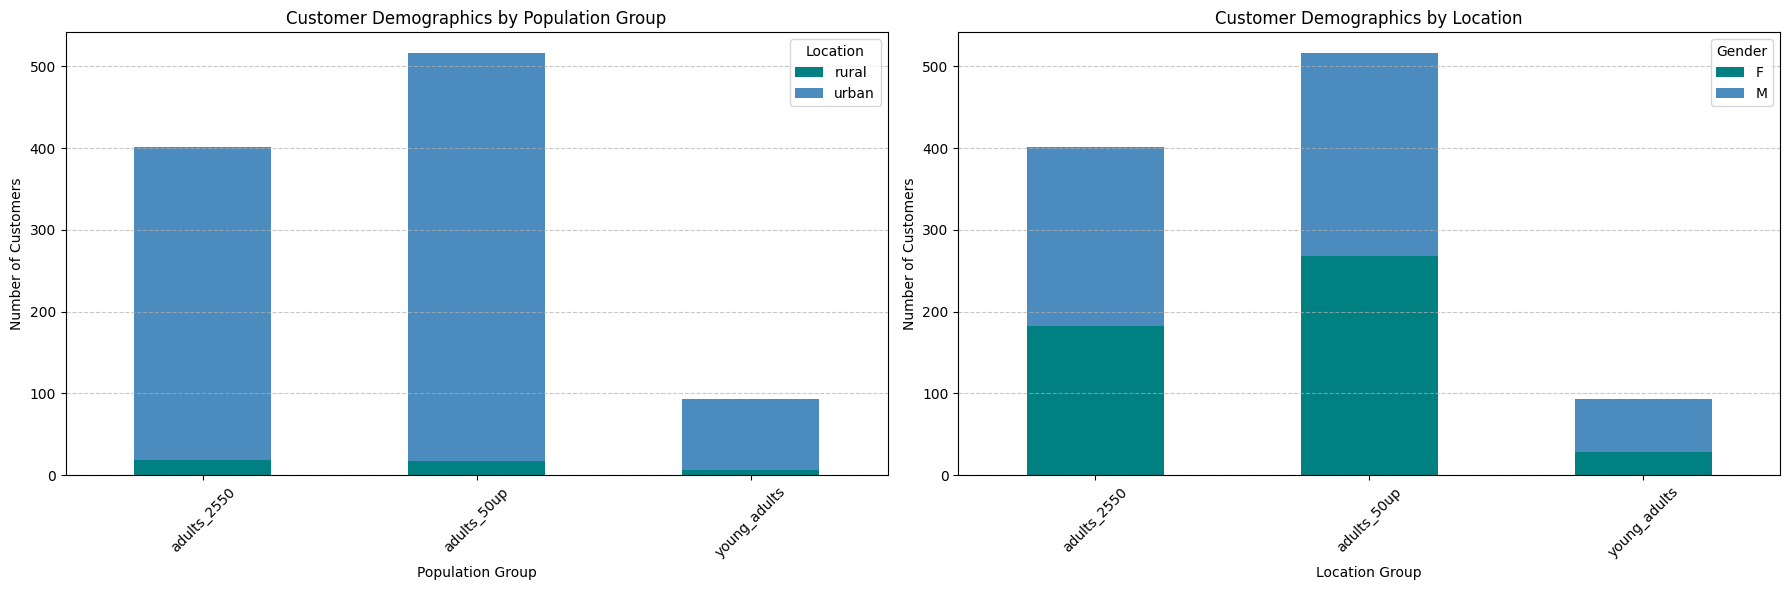

In [30]:
# Customer demographics analysis - Using an stacked bar plot
print("Customers - Preliminary Demographics Analysis:\n")

# Population group distribution
pop_group_dist = customers_df['pop_group'].value_counts()
print(f"\nPopulation Group Distribution:")
for pop_group, count in pop_group_dist.items():
    print(f"  {pop_group}: {count} ({count/len(customers_df)*100:.1f}%)")

location_dist = customers_df['location'].value_counts()
print(f"\nLocation Distribution:")
for location, count in location_dist.items():
    print(f"  {location}: {count} ({count/len(customers_df)*100:.1f}%)")

gender_dist = customers_df['gender'].value_counts()
print(f"\nGender Distribution:")
for gender, count in gender_dist.items():
    print(f"  {gender}: {count} ({count/len(customers_df)*100:.1f}%)")

# Plotting Groups/Locations
# Create cross-tabulation
# https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.crosstab.html
# https://www.geeksforgeeks.org/python/pandas-crosstab-function-in-python/

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
customers_cross_loc = pd.crosstab(customers_df['pop_group'], customers_df['location'])

customers_cross_loc.plot(kind='bar', stacked=True, color=[color_teal, color_blue], ax=axes[0])
axes[0].set_title('Customer Demographics by Population Group')
axes[0].set_xlabel('Population Group')
axes[0].set_ylabel('Number of Customers')
axes[0].legend(title='Location')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
# Location distribution



# Plotting
customers_cross_gender = pd.crosstab(customers_df['pop_group'], customers_df['gender'])
customers_cross_gender.plot(kind='bar', stacked=True, color=[color_teal, color_blue], ax=axes[1])

axes[1].set_title('Customer Demographics by Location')
axes[1].set_xlabel('Location Group')
axes[1].set_ylabel('Number of Customers')
axes[1].legend(title='Gender')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


Top 10 States by Customer Count:
  CA: 132 customers
  TX: 80 customers
  NY: 63 customers
  FL: 48 customers
  PA: 47 customers
  MI: 39 customers
  NC: 34 customers
  OH: 31 customers
  IL: 30 customers
  GA: 29 customers


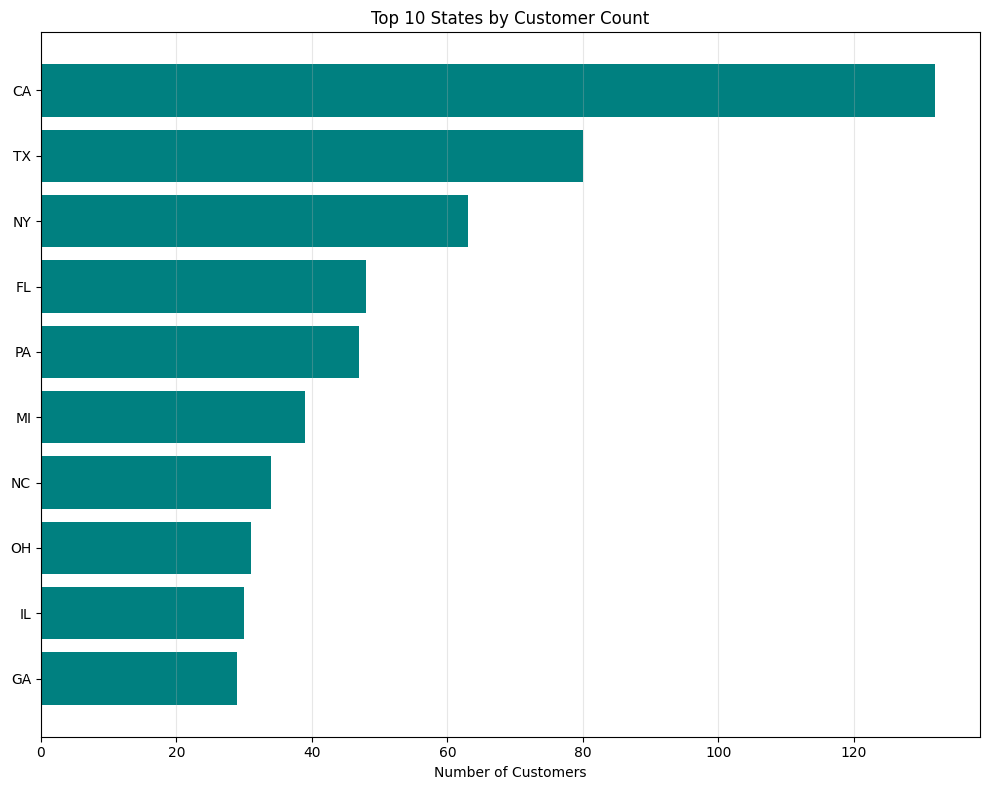

In [31]:
# Top 10 States
num_states_viz = 10
state_counts = customers_df['state'].value_counts().head(num_states_viz)

print(f"\nTop {num_states_viz} States by Customer Count:")
for state, count in state_counts.items():
    print(f"  {state}: {count} customers")
    
plt.figure(figsize=(10, 8))
# Convert to list to avoid array type issues
plt.barh(range(len(state_counts)), list(state_counts.values), color=color_teal)
plt.yticks(range(len(state_counts)), list(state_counts.index))
plt.xlabel('Number of Customers')
plt.title(f'Top {num_states_viz} States by Customer Count')
plt.grid(True, alpha=0.3, axis='x')
plt.gca().invert_yaxis()  # Put highest at top
plt.tight_layout()
plt.show()

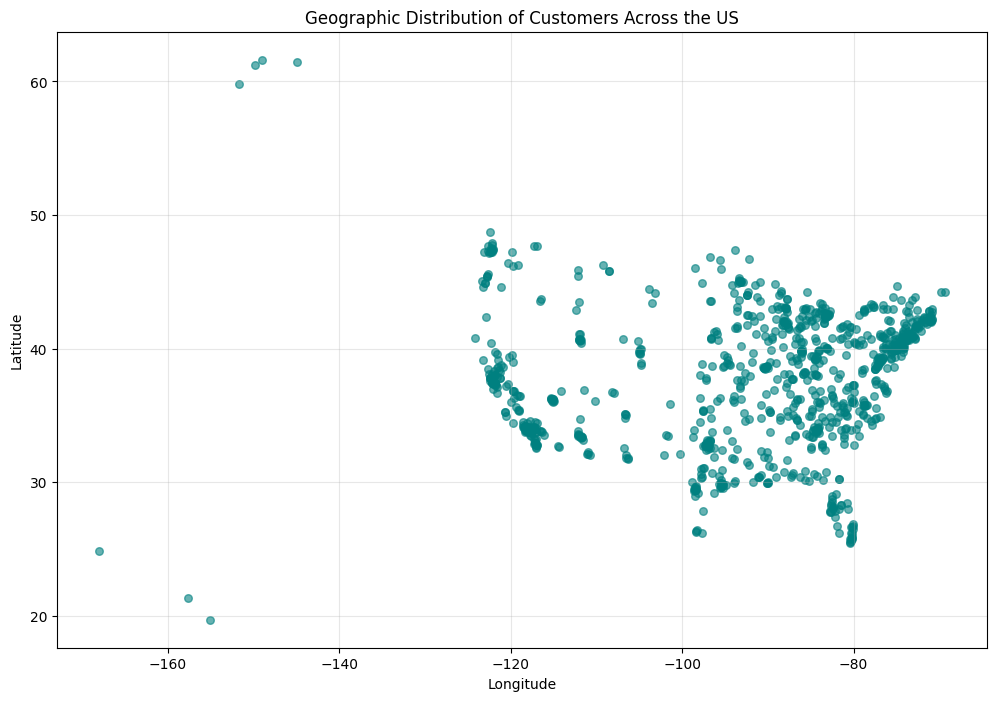

In [32]:
# Geographic distribution - Using a scatter plot
plt.figure(figsize=(12, 8))
plt.scatter(customers_df['long'], customers_df['lat'], 
           c=color_teal,  alpha=0.6, s=30)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Geographic Distribution of Customers Across the US')
plt.grid(True, alpha=0.3)
plt.show()

In [33]:

import plotly.express as px
import pandas as pd

data = {
    "City": ["New York", "Los Angeles", "Chicago", "Houston", "Phoenix"],
    "Latitude": [40.7128, 34.0522, 41.8781, 29.7604, 33.4484],
    "Longitude": [-74.0060, -118.2437, -87.6298, -95.3698, -112.0740],
    "Population": [8419600, 3980400, 2716000, 2328000, 1690000]
}
df = pd.DataFrame(data)


fig = px.scatter_mapbox(
    df,
    lat="Latitude",
    lon="Longitude",
    hover_name="City",
    hover_data=["Population"],
    color="Population",
    size="Population",
    color_continuous_scale=px.colors.cyclical.IceFire,
    size_max=15,
    zoom=3,
    mapbox_style="carto-positron"
)

fig.show()
"""
Key Parameters Explained
lat & lon: Columns for latitude and longitude.
hover_name: Text displayed when hovering over points.
color & size: Customize marker color and size based on data.
mapbox_style: Choose from styles like "carto-positron", "open-street-map", etc.
zoom: Adjust the initial zoom level.
Optional: Mapbox Token

For advanced customization, you may need a Mapbox token. Sign up at Mapbox and set it:

Copy the code
px.set_mapbox_access_token("your_mapbox_token_here")


This will create an interactive scatter map where you can zoom, pan, and explore your data visually!
"""

C:\Users\lcabr\AppData\Local\Temp\ipykernel_47108\1749915176.py:13: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



'\nKey Parameters Explained\nlat & lon: Columns for latitude and longitude.\nhover_name: Text displayed when hovering over points.\ncolor & size: Customize marker color and size based on data.\nmapbox_style: Choose from styles like "carto-positron", "open-street-map", etc.\nzoom: Adjust the initial zoom level.\nOptional: Mapbox Token\n\nFor advanced customization, you may need a Mapbox token. Sign up at Mapbox and set it:\n\nCopy the code\npx.set_mapbox_access_token("your_mapbox_token_here")\n\n\nThis will create an interactive scatter map where you can zoom, pan, and explore your data visually!\n'

In [39]:
# US State abbreviation to full name mapping
us_states = {
    'AL': 'Alabama', 'AK': 'Alaska', 'AZ': 'Arizona', 'AR': 'Arkansas', 'CA': 'California',
    'CO': 'Colorado', 'CT': 'Connecticut', 'DE': 'Delaware', 'FL': 'Florida', 'GA': 'Georgia',
    'HI': 'Hawaii', 'ID': 'Idaho', 'IL': 'Illinois', 'IN': 'Indiana', 'IA': 'Iowa',
    'KS': 'Kansas', 'KY': 'Kentucky', 'LA': 'Louisiana', 'ME': 'Maine', 'MD': 'Maryland',
    'MA': 'Massachusetts', 'MI': 'Michigan', 'MN': 'Minnesota', 'MS': 'Mississippi', 'MO': 'Missouri',
    'MT': 'Montana', 'NE': 'Nebraska', 'NV': 'Nevada', 'NH': 'New Hampshire', 'NJ': 'New Jersey',
    'NM': 'New Mexico', 'NY': 'New York', 'NC': 'North Carolina', 'ND': 'North Dakota', 'OH': 'Ohio',
    'OK': 'Oklahoma', 'OR': 'Oregon', 'PA': 'Pennsylvania', 'RI': 'Rhode Island', 'SC': 'South Carolina',
    'SD': 'South Dakota', 'TN': 'Tennessee', 'TX': 'Texas', 'UT': 'Utah', 'VT': 'Vermont',
    'VA': 'Virginia', 'WA': 'Washington', 'WV': 'West Virginia', 'WI': 'Wisconsin', 'WY': 'Wyoming',
    'DC': 'District of Columbia'
}

# Add full state names to your dataframe
customers_df['state_full'] = customers_df['state'].map(us_states)

# Check for any unmapped states
unmapped = customers_df[customers_df['state_full'].isna()]['state'].unique()
if len(unmapped) > 0:
    print(f"Unmapped state codes: {unmapped}")

In [ ]:
# PLOTLY - Interactive Scatter Map
# https://www.datacamp.com/tutorial/making-map-in-python-using-plotly-library-guide
import plotly.express as px

customers_df['full_name'] = customers_df['first'] + ' ' + customers_df['last']

# Create scatter mapbox
fig = px.scatter_map(
    customers_df,
    lat='lat',
    lon='long',
    color='state',
    hover_name='full_name',
    hover_data=['city', 'state_full', 'city_pop', 'job'],  #customdata
    zoom=3,
    height=600,
    title='Customer Geographic Distribution',
    map_style='open-street-map'
)

fig.update_traces(
    hovertemplate="<b>%{hovertext}</b><br>" +
                  "City: %{customdata[0]}<br>" +
                  "State: %{customdata[1]}<br>" +
                  "Population: %{customdata[2]:,}<br>" +
                  "Job: %{customdata[3]}<br>" +
                  "<extra></extra>"  # This removes lat and long from hover
)
"""
fig.update_traces(
    hovertemplate="<b>%{customdata[0]}</b><br>" +
                  "State: %{customdata[1]}<br>" +
                  "Location: %{lat:.2f}, %{lon:.2f}<br>" +
                  "<extra></extra>"

)

fig.update_layout(
    mapbox=dict(
        center=dict(lat=39.8283, lon=-98.5795),
        zoom=3
    ),
    margin={"r":0,"t":50,"l":0,"b":0}
)
fig.update_layout(
    title_font_size=16,
    title_x=0.5,  # Center title
    showlegend=True,
    legend=dict(orientation="v", x=1.02, y=1)
)
"""

fig.show()

### Transaction analysis

In [ ]:
# Load transaction data from the database
transactions_df = pd.read_sql_query("SELECT * FROM transactions", conn)

In [ ]:
uf.show_df_info(transactions_df)

In [ ]:
# Transaction analysis from sample
print("**** TRANSACTION ANALYSIS (Sample) ****\n")

# Transaction categories
if 'category' in sample_transactions_df.columns:
    category_dist = sample_transactions_df['category'].value_counts()
    print(f"\nTransaction Categories (from sample file):")
    for category, count in category_dist.items():
        print(f"  {category}: {count} ({count/len(sample_transactions_df)*100:.1f}%)")

# Amount statistics
if 'amt' in sample_transactions_df.columns:
    print(f"\nTransaction Amount Statistics (from sample):")
    print(f"  Mean: ${sample_transactions_df['amt'].mean():.2f}")
    print(f"  Median: ${sample_transactions_df['amt'].median():.2f}")
    print(f"  Min: ${sample_transactions_df['amt'].min():.2f}")
    print(f"  Max: ${sample_transactions_df['amt'].max():.2f}")
    print(f"  Std Dev: ${sample_transactions_df['amt'].std():.2f}")

# Fraud statistics
if 'is_fraud' in sample_transactions_df.columns:
    fraud_dist = sample_transactions_df['is_fraud'].value_counts()
    fraud_rate = fraud_dist.get(1, 0) / len(sample_transactions_df) * 100
    print(f"\nFraud Statistics (from sample):")
    print(f"  Legitimate Transactions: {fraud_dist.get(0, 0)}")
    print(f"  Fraudulent Transactions: {fraud_dist.get(1, 0)}")
    print(f"  Fraud Rate: {fraud_rate:.2f}%")